# P.I.T.E. (Physics-informed transpiration estimates)

Using physics-informed machine learning on eddy covariance data to predict the transpiration ratio (T/ET)

Built using PyTorch

---


We'll start by checking the machine for GPUs
- if you have a GPU and the code is not able to find it, you may need to update your software (often NVIDIA drivers and/or CUDA toolkit)
- the model can run on a CPU if no GPU is available

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


### Now we can load in the data and check for variables

Replace filepath with your data. The data should be formatted with FLUXNET guidelines.
- timestamps should be formatted like YYYYMMDDHHMM

In [ ]:
#data loading and preparation 

#example dataset from CA-ER1, an agricultural site with rotating crops
#ideally the corn years would be separated from the soybean years and PITE would train on each individual crop
#this is just an example and they've been kept together for now
sitedata = pd.read_csv(r'D:\Emma\Model\Elora data\AMF_CA-ER1_FLUXNET_SUBSET_HH_2015-2020_3-5.csv')
sitedata = sitedata.replace(-9999, np.nan)
sitedata['time_str'] = pd.to_datetime(sitedata['TIMESTAMP_START'], format='%Y%m%d%H%M')

variables = list(sitedata.columns.values)

#checking for the following variables in the dataset
targetfeatures = ['TA_F','VPD_F','USTAR', 'NETRAD', 'NEE_VUT_REF', 'P_F', 'PA_F', 'WS_F', 'H_F_MDS', 'G_F_MDS', 'SW_IN_POT', 'TS_F_MDS_1', 'SWC_F_MDS_1', 'LE_F_MDS']
finalfeatures = []

for var in targetfeatures:
    if var in variables:
        #skip features with more than 30% of missing data
        if sitedata[var].isna().mean() > 0.3:
            continue
        else:
            finalfeatures.append(var)

#if all variables are found, we want to get rid of some due to multicollinearity
if 'NETRAD' in finalfeatures and 'SW_IN_POT' in finalfeatures:
    finalfeatures.remove('SW_IN_POT')
if 'G_F_MDS' in finalfeatures:
    for var in ['TS_F_MDS_1', 'SWC_F_MDS_1']:
        if var in finalfeatures:
            finalfeatures.remove(var)

#only want the desired variables to be used as input features
modeldata = sitedata[finalfeatures].copy()
modeldata['timestamp_asstring'] = sitedata['TIMESTAMP_START'].astype(str)
modeldata['TOD'] = modeldata['timestamp_asstring'].str[8:]
modeldata['TOD'] = modeldata['TOD'].astype(int)

### Some feature engineering

- ecosystem water use efficiency
- time since last rainfall (give information on surface water availability)

In [4]:
#linear interpolate USTAR before dropping NaNs, ustar is the only un-gapfilled col
if 'USTAR' in modeldata.columns:
    modeldata['USTAR'] = modeldata['USTAR'].interpolate(method='linear', limit_direction='both')

#rough calculation of ecosystem WUE

#ET mm/s or Kg/m2/s
modeldata['ET'] = modeldata['LE_F_MDS'] / ((2.501 - (0.00237 * modeldata['TA_F'] )) * 1e+06)
#WUE g C hpa^0.5 / Kg H2O 
modeldata['WUE'] = (-(modeldata['NEE_VUT_REF'] * 12.01 / 1000000) * np.sqrt(modeldata['VPD_F'])) / modeldata['ET']

#how long since the last rainfall? 
def time_since_rain(P_F):
    result = np.zeros(len(P_F))
    counter = 0
    for i, val in enumerate(P_F):
        if val > 0:
            counter = 0
        else:
            counter += 1
        result[i] = counter
    return result
modeldata['P_time'] = time_since_rain(modeldata['P_F'].values)

#then drop ET and LE as input feature
modeldata = modeldata.drop(columns=['ET', 'LE_F_MDS', 'timestamp_asstring'])
modeldata = modeldata.dropna()
finalfeatures = modeldata.columns
finalfeatures = finalfeatures.drop(['TOD'])

### Because PITE is built on a neural network, we need to scale all input features

Scaling
- mean of 0
- standard deviation of 1

In [5]:
#scaling
scaledfeatures = pd.DataFrame()
for var in finalfeatures:
    scaled = (modeldata[var] - modeldata[var].mean()) / (modeldata[var].std())
    scaledfeatures[var] = scaled

#insert TOD as first column
scaledfeatures.insert(0, 'TOD', modeldata['TOD'])

#the timestep needs to be scaled separately to encode information on the time of day
#timesteps are now in fractions out of 48
def fraction_time(tod):
    tod = str(tod).zfill(4)
    hh = int(tod[:2])
    mm = int(tod[2:])
    return (hh + mm / 60) / 24
scaledfeatures['TOD'] = scaledfeatures['TOD'].apply(fraction_time)

print(scaledfeatures.head(4))

        TOD      TA_F     VPD_F     USTAR  NEE_VUT_REF       P_F      PA_F  \
0  0.000000 -1.521654 -0.682787  1.646108     0.531980 -0.116659 -0.408486   
1  0.020833 -1.521925 -0.682787  1.646108     0.570447 -0.116659 -0.454101   
2  0.041667 -1.522286 -0.682787  1.646108     0.603554 -0.146426 -0.498375   
3  0.062500 -1.513163 -0.682787  1.646108     0.629444 -0.146426 -0.527891   

       WS_F   H_F_MDS  SW_IN_POT      WUE    P_time  
0  1.202485 -0.403331  -0.790895 -0.00161 -0.586121  
1  1.243518 -0.381177  -0.790895 -0.00161 -0.586121  
2  1.283972 -0.347237  -0.790895 -0.00161 -0.586121  
3  1.250453 -0.339993  -0.790895 -0.00161 -0.586121  


# Time to build the model

---

### We can add physics into the model using differential equations

Assuming that transpiration follows a sine curve over a diel cycle, and that at somepoint during that cycle (overnight) transpiration is negligible

$$
\frac{dTET}{dt} = A * cos(\omega t + \Phi)
$$

where: A = amplitude, $\omega$ = $\frac{2\pi}{24}$, $\Phi$ = phase
with a solution of

$$
\frac{d^2 TET}{dt^2} + \omega^2 TET = 0
$$

The second derivative brings us to the simple harmonic oscillator equation which allows changing amplitudes

In [ ]:
#the code below is within the model framework and is responsible for computing the 2nd derivative
"""
def compute_pde_residual(model, x_pde):
    omega = 2 * np.pi / 24
    #first derivative
    y_pde = model(x_pde)
    dyt = torch.autograd.grad(
        outputs = y_pde,
        inputs = x_pde,
        grad_outputs = torch.ones_like(y_pde),
        create_graph=True,
        retain_graph=True
    )[0]

    sum_dyt = dyt.sum(dim=-1, keepdim=True)

    #second derivative
    laplacian = torch.autograd.grad(
        outputs= sum_dyt,
        inputs= x_pde,
        grad_outputs= torch.ones_like(sum_dyt),
        create_graph=True,
        retain_graph=True
    )[0].sum(dim=-1, keepdim=True)

    pde_residual = laplacian + (omega**2) * sum_dyt
    return pde_residual, y_pde
"""

### Now to ground the model in realistic values, we create boundary conditions to describe the system

Lower bound
- when NEE is positive (overnight and during fallow periods), T = 0

Upper bounds
- when the ecosystem is in its hottest and driest conditions, E = 0
- if it's actively raining and VPD is low, E = 0

In [ ]:
# lower bound
x_fallowunscaled = modeldata[modeldata['NEE_VUT_REF'] > 2.5] #this parameter can be changed to better suit your ecosystem. If you have a single year of data, try lower values
fallow_indices = x_fallowunscaled.index
x_fallow = scaledfeatures.loc[fallow_indices]

# upper bounds
x_upper_tavpd = scaledfeatures[(scaledfeatures['TA_F']  >= np.percentile(scaledfeatures['TA_F'], 99))
                             & (scaledfeatures['VPD_F'] >= np.percentile(scaledfeatures['VPD_F'], 99))]

x_rainyunscaled = modeldata[(modeldata['P_F'] > 0.1) & (modeldata['VPD_F'] <= np.percentile(modeldata['VPD_F'], 5))]
rainy_indices = x_rainyunscaled.index
x_rainy = scaledfeatures.loc[rainy_indices]

#tensors
x_hotanddry = torch.tensor(x_upper_tavpd.values, dtype=torch.float32).to(device)
y_hotanddry_target = torch.ones((x_hotanddry.shape[0], 1), dtype=torch.float32).to(device)

x_fallow_t = torch.tensor(x_fallow.values, dtype=torch.float32).to(device)
y_fallow_target = torch.zeros((x_fallow_t.shape[0], 1), dtype=torch.float32).to(device)

x_rainy_t = torch.tensor(x_rainy.values, dtype=torch.float32).to(device)
y_rainy_target = torch.ones((x_rainy_t.shape[0], 1), dtype=torch.float32).to(device)

x_pde = torch.tensor(scaledfeatures.values, dtype=torch.float32, requires_grad=True).to(device)

### Loss is calculated using both the boundary conditions and the PDE we just defined
$L_{total}$ = $L_{BC}$ + $L_{PDE}$

In [21]:
def calculate_loss(y_hotanddry_pred, y_fallow_pred, y_rainy_pred, pde_residual,
                   y_hotanddry_target, y_fallow_target, y_rainy_target):
    loss_hotanddry = torch.mean((y_hotanddry_pred - y_hotanddry_target)**2)
    loss_fallow    = torch.mean((y_fallow_pred - y_fallow_target)**2)
    loss_rainy    = torch.mean((y_rainy_pred - y_rainy_target)**2)
    loss_pde       = torch.mean(pde_residual**2)
    total_loss = loss_hotanddry + loss_fallow + loss_rainy + loss_pde
    return total_loss, loss_hotanddry, loss_fallow, loss_rainy, loss_pde

### Model architecture

- ensemble model, will run 7 models in parallel and take the average and standard deviation of all predictions for final output 
- can adjust how many models are including in the ensemble. more models = higher certainty = more computational time required

- densely connected, feed-forward neural network
- 4 hidden layers with varying nodes to imitate a simple encoder / decoder process
- adamW optimizer

In [22]:
class PINNEnsemble:
    def __init__(self, input_dim, n_models=7, device='cuda'):
        self.n_models = n_models
        self.device = device
        self.models = []
        self.optimizers = []
        
        # create n_models with different random initializations
        for i in range(n_models):
            model = nn.Sequential(
                nn.Linear(input_dim, 60), nn.ReLU(),
                nn.Linear(60, 6), nn.ReLU(),
                nn.Linear(6, 60), nn.ReLU(),
                nn.Linear(60, 1), nn.Sigmoid()
            ).to(device)
            
            self.models.append(model)
            self.optimizers.append(optim.AdamW(model.parameters()))
    
    def train_ensemble(self, x_hotanddry, y_hotanddry_target,
                       x_fallow_t, y_fallow_target,
                       x_rainy_t, y_rainy_target,
                       x_pde, epochs=2000, subsample_fraction=0.8):
        """
        x_pde: full set of collocation points
        subsample_fraction: fraction of collocation points to use per model per epoch
        """
        
        n_collocation = len(x_pde)
        subsample_size = int(n_collocation * subsample_fraction)
        
        # store losses for monitoring
        all_losses = {f'model_{i}': [] for i in range(self.n_models)}
        
        for epoch in range(epochs):
            epoch_losses = {f'model_{i}': {} for i in range(self.n_models)}
            
            for model_idx, (model, optimizer) in enumerate(zip(self.models, self.optimizers)):
                model.train()
                optimizer.zero_grad()
                
                # **collocation subsampling**: randomly select subset for this model
                subsample_idx = np.random.choice(
                    n_collocation, 
                    size=subsample_size, 
                    replace=False
                )
                x_pde_subset = x_pde[subsample_idx]
                
                # forward pass with BC data
                y_hotanddry_pred = model(x_hotanddry)
                y_fallow_pred = model(x_fallow_t)
                y_rainy_pred = model(x_rainy_t)
                
                # PDE residual on subsampled collocation points
                pde_residual, _ = self.compute_pde_residual(model, x_pde_subset)
                
                # loss calculation
                total_loss, loss_hotanddry, loss_fallow, loss_rainy, loss_pde = calculate_loss(
                    y_hotanddry_pred, y_fallow_pred, y_rainy_pred, pde_residual,
                    y_hotanddry_target, y_fallow_target, y_rainy_target
                )
                
                total_loss.backward()
                optimizer.step()
                
                # store losses
                epoch_losses[f'model_{model_idx}'] = {
                    'total': total_loss.item(),
                    'pde': loss_pde.item(),
                    'hotanddry': loss_hotanddry.item(),
                    'fallow': loss_fallow.item(),
                    'rainy': loss_rainy.item()
                }
            
            # print progress (ensemble average)
            if epoch % 100 == 0:
                avg_total = np.mean([epoch_losses[f'model_{i}']['total'] for i in range(self.n_models)])
                avg_pde = np.mean([epoch_losses[f'model_{i}']['pde'] for i in range(self.n_models)])
                avg_hotanddry = np.mean([epoch_losses[f'model_{i}']['hotanddry'] for i in range(self.n_models)])
                avg_fallow = np.mean([epoch_losses[f'model_{i}']['fallow'] for i in range(self.n_models)])
                avg_rainy = np.mean([epoch_losses[f'model_{i}']['rainy'] for i in range(self.n_models)])
                
                print(f'Epoch {epoch}: Ensemble Avg Loss = {avg_total:.6f}')
                print(f'    pde loss: {avg_pde:.6f} | '
                      f'hotanddry loss: {avg_hotanddry:.6f} | '
                      f'fallow loss: {avg_fallow:.6f} | '
                      f'rainy loss: {avg_rainy:.6f}')
                print()
    
    @staticmethod
    #compute pde residual
    def compute_pde_residual(model, x_pde):
        omega = 2 * np.pi / 24
        # first derivative
        y_pde = model(x_pde)
        dyt = torch.autograd.grad(
            outputs=y_pde,
            inputs=x_pde,
            grad_outputs=torch.ones_like(y_pde),
            create_graph=True,
            retain_graph=True
        )[0]
        sum_dyt = dyt.sum(dim=-1, keepdim=True)
        
        #second derivative
        laplacian = torch.autograd.grad(
            outputs=sum_dyt,
            inputs=x_pde,
            grad_outputs=torch.ones_like(sum_dyt),
            create_graph=True,
            retain_graph=True
        )[0].sum(dim=-1, keepdim=True)
        
        pde_residual = laplacian + (omega**2) * sum_dyt
        return pde_residual, y_pde
    
    def predict(self, x):
        #returns mean and std of predictions
        predictions = []
        
        for model in self.models:
            model.eval()
            with torch.no_grad():
                pred = model(x).cpu().numpy()
                predictions.append(pred)
        
        predictions = np.array(predictions)
        mean_pred = np.mean(predictions, axis=0)
        std_pred = np.std(predictions, axis=0)
        
        return mean_pred, std_pred

### Train and predict

In [26]:
# initialize ensemble
input_dim = len(finalfeatures) + 1
ensemble = PINNEnsemble(input_dim=input_dim, n_models=7, device=device)

# make sure x_pde requires grad for autograd for PDE calculation will fail
x_pde.requires_grad_(True)
x_hotanddry.requires_grad_(True)
x_fallow_t.requires_grad_(True)
x_rainy_t.requires_grad_(True)

# train ensemble
ensemble.train_ensemble(
    x_hotanddry, y_hotanddry_target,
    x_fallow_t, y_fallow_target,
    x_rainy_t, y_rainy_target,
    x_pde,
    epochs=2000,
    subsample_fraction=0.8  # use 80% of collocation points per model
)

# predictions with uncertainty
x_test = torch.tensor(scaledfeatures.values, dtype=torch.float32).to(device)
x_test.requires_grad_(True)
mean_predictions, std_predictions = ensemble.predict(x_test)

Epoch 0: Ensemble Avg Loss = 0.735103
    pde loss: 0.000000 | hotanddry loss: 0.233884 | fallow loss: 0.259343 | rainy loss: 0.241875

Epoch 100: Ensemble Avg Loss = 0.165762
    pde loss: 0.002641 | hotanddry loss: 0.006683 | fallow loss: 0.111127 | rainy loss: 0.045311

Epoch 200: Ensemble Avg Loss = 0.091659
    pde loss: 0.000658 | hotanddry loss: 0.002384 | fallow loss: 0.078073 | rainy loss: 0.010544

Epoch 300: Ensemble Avg Loss = 0.078766
    pde loss: 0.000440 | hotanddry loss: 0.001661 | fallow loss: 0.068493 | rainy loss: 0.008172

Epoch 400: Ensemble Avg Loss = 0.056653
    pde loss: 0.000483 | hotanddry loss: 0.001260 | fallow loss: 0.046362 | rainy loss: 0.008548

Epoch 500: Ensemble Avg Loss = 0.036693
    pde loss: 0.000276 | hotanddry loss: 0.000890 | fallow loss: 0.029488 | rainy loss: 0.006040

Epoch 600: Ensemble Avg Loss = 0.027110
    pde loss: 0.000131 | hotanddry loss: 0.000601 | fallow loss: 0.022805 | rainy loss: 0.003573

Epoch 700: Ensemble Avg Loss = 0.023

### How are the predictions looking?

In [27]:
x_all = torch.tensor(scaledfeatures.values, dtype=torch.float32).to(device)

# individual model stats
for i, model in enumerate(ensemble.models):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_all)
    print(f'Model {i} - Max: {y_pred.max().item()}, Min: {y_pred.min().item()}, Mean: {y_pred.mean().item()}')

# ensemble stats
mean_pred, std_pred = ensemble.predict(x_all)
print(f'\nEnsemble Mean - Max: {mean_pred.max()}, Min: {mean_pred.min()}, Mean: {mean_pred.mean()}')
print(f'Ensemble Std - Mean: {std_pred.mean()}')

Model 0 - Max: 1.0, Min: 0.0, Mean: 0.1248074471950531
Model 1 - Max: 1.0, Min: 0.0, Mean: 0.12805142998695374
Model 2 - Max: 1.0, Min: 0.0, Mean: 0.1281353086233139
Model 3 - Max: 1.0, Min: 0.0, Mean: 0.1429269164800644
Model 4 - Max: 1.0, Min: 0.0, Mean: 0.13695456087589264
Model 5 - Max: 1.0, Min: 1.3493295339005329e-27, Mean: 0.14261901378631592
Model 6 - Max: 1.0, Min: 0.0, Mean: 0.10342302173376083

Ensemble Mean - Max: 1.0, Min: 1.1269590721739214e-16, Mean: 0.1295596808195114
Ensemble Std - Mean: 0.030986379832029343


### Lastly, a simple graph to look at the annual patterns

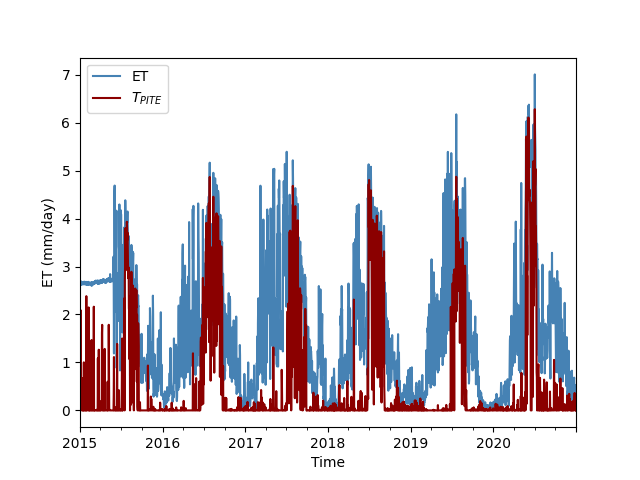

In [28]:
%matplotlib widget
modelindicies = scaledfeatures.index
graphdata = sitedata.loc[modelindicies]
graphdata['TIMESTAMP_START'] = pd.to_datetime(graphdata['TIMESTAMP_START'], format='%Y%m%d%H%M')
graphdata = graphdata.set_index('TIMESTAMP_START')
graphdata['y_pred'] = y_pred.cpu().numpy()
graphdata['y_std'] = std_pred

graphdata['ET'] = graphdata['LE_F_MDS'] / ((2.501 - (0.00237 * graphdata['TA_F'] )) * 1e+06)
graphdata['ET'] = graphdata['ET'].where(graphdata['ET'] > 0, np.nan)
# currently in mm/s but should be in mm/HH so necessary conversion
graphdata['ET'] = graphdata['ET'] * 60 * 30
graphdata['TET'] = graphdata['ET'] * graphdata['y_pred']

daily_ET = graphdata['ET'].resample('D').sum()
daily_T = graphdata['TET'].resample('D').sum()

# plot ET and T_PITE
fig, ax1 = plt.subplots()
daily_ET.plot(ax=ax1, label='ET', color='steelblue')
daily_T.plot(ax=ax1, label=r'$T_{PITE}$', color='darkred')
ax1.set_ylabel('ET (mm/day)')
ax1.set_xlabel('Time')
ax1.legend()
plt.show()